In [0]:
from collections import defaultdict
import numpy as np

# assume at least one point; get embedding length
emb_len = len(points[0].raw_embedding2)

center_additions = defaultdict(lambda: np.zeros(emb_len, dtype=float))
center_counts = defaultdict(int)

center_reduced_additions = defaultdict(lambda: np.zeros(2, dtype=float))
center_reduced_counts = defaultdict(int)

for point in points:
    sector = point.metadata["sector"]
    center_additions[sector] += np.asarray(point.raw_embedding2, dtype=float)
    center_counts[sector] += 1

    center_reduced_additions[sector] += np.asarray(point.embedding, dtype=float)
    center_reduced_counts[sector] += 1



centers = {s: center_additions[s] / center_counts[s] for s in center_additions if len(s) > 0}

centers_reduced = {s: center_reduced_additions[s] / center_reduced_counts[s] for s in center_reduced_additions if len(s) > 0}

In [0]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


In [0]:
centers = list(centers.items())

sector_names, vecs = zip(*centers)
vecs = np.stack(vecs)

# Normalize vectors (protect against zero norms)
norms = np.linalg.norm(vecs, axis=1, keepdims=True)
norms[norms == 0] = 1.0
unit_vecs = vecs / norms

# Pairwise cosine similarity via matrix multiply
pairwise = unit_vecs @ unit_vecs.T

pairwise_by_sector = {
    s: dict(zip(sector_names, row))
    for s, row in zip(sector_names, pairwise)
}


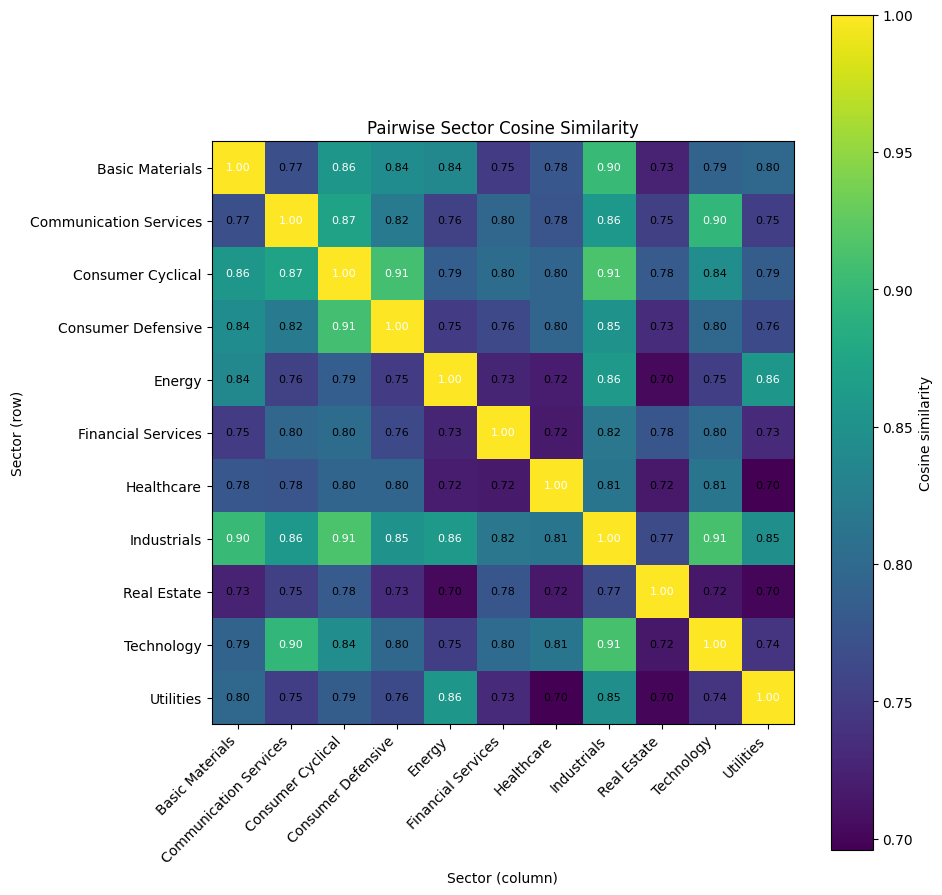

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Build ordered list of sector names
sectors = sorted(pairwise_by_sector.keys())

# Construct matrix
conf_mat = np.array([[pairwise_by_sector[r][c] for c in sectors] for r in sectors], dtype=float)

vmin = float(conf_mat.min())
vmax = float(conf_mat.max())

# Avoid zero range (all values identical)
if np.isclose(vmin, vmax):
    vmin -= 1e-6
    vmax += 1e-6

fig, ax = plt.subplots(figsize=(0.6 * len(sectors) + 3, 0.6 * len(sectors) + 3))
im = ax.imshow(conf_mat, cmap="viridis", vmin=vmin, vmax=vmax)

ax.set_xticks(range(len(sectors)))
ax.set_yticks(range(len(sectors)))
ax.set_xticklabels(sectors, rotation=45, ha="right")
ax.set_yticklabels(sectors)

ax.set_xlabel("Sector (column)")
ax.set_ylabel("Sector (row)")
ax.set_title("Pairwise Sector Cosine Similarity")

for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        ax.text(
            j, i, f"{conf_mat[i, j]:.2f}",
            ha="center", va="center",
            color="white" if (conf_mat[i, j] - vmin) / (vmax - vmin + 1e-12) > 0.5 else "black",
            fontsize=8
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Cosine similarity")

plt.tight_layout()
plt.show()

In [0]:
widget = SectorSimilarity(
    [(service, list(vec)) for service, vec in centers],
    {sector: {subsector: float(value) for subsector, value in list(sector_values.items())} for sector, sector_values in list(pairwise_by_sector.items())},
    conf_mat.tolist(),
    sectors
)

UI.addWidget(widget)
